# 15. From Alerts to Root Cause Analysis

An anomaly detector can tell us that something is unusual. It cannot, by itself, tell us what caused the unusual behavior, what should be fixed first, or whether the apparent explanation is only a downstream symptom.

This notebook studies the transition from **alerting** to **root-cause analysis**. The goal is not to prove causality from telemetry alone. The goal is to build a defensible incident hypothesis using anomaly scores, service topology, temporal ordering, operational knowledge, and decision costs.

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain why the highest anomaly score is not necessarily the root cause.
- Combine topology, timing, blast radius, and local anomaly evidence into a root-cause ranking.
- Distinguish symptoms, mechanisms, candidate causes, and recommended actions.
- Use dependency graphs to reason about propagation without overclaiming causal proof.
- Produce an incident memo that states evidence, uncertainty, and next actions.

## 1. Why Alerts Are Not Root Causes

In operations, a detector often raises an alert at the place where harm is most visible. For example, customers may see checkout latency, but the source may be a payment provider, an inventory lock, a queue saturation problem, a deployment, or a network issue.

A useful root-cause workflow therefore asks several different questions.

| Question | What it tells us | What it does not prove |
|---|---|---|
| Which metric became unusual? | The visible symptom | The initiating mechanism |
| Which service failed first? | Temporal evidence | That it caused every later symptom |
| Which services depend on it? | Propagation plausibility | That the dependency was active for this incident |
| Which component has the largest score? | Local severity | Root cause or action priority |
| Which intervention would stop the issue? | Decision relevance | Guaranteed success without testing |

RCA research for cloud and microservice systems commonly uses dependency graphs, KPI telemetry, logs, and anomaly propagation ideas because production systems are too interconnected for isolated metric inspection (Wang et al., 2018; Liu et al., 2021; Zhang et al., 2021).

## 2. Mathematical Setup

Let a monitored platform contain services

$$
V = \{1, 2, \ldots, m\},
$$

and let the directed dependency graph be

$$
G = (V, E),
$$

where an edge $u \to v$ means that an incident in service $u$ can plausibly propagate to service $v$.

For service $s$, time $t$, and metric $k$, let

$$
Y_{s,t,k}
$$

be the observed telemetry value. A detector converts telemetry into a service-level anomaly score

$$
A_{s,t} = f(Y_{s,t,1}, Y_{s,t,2}, \ldots, Y_{s,t,p}).
$$

An alert fires for service $s^\star$ at time $t^\star$ when

$$
A_{s^\star,t^\star} \geq \tau.
$$

Root-cause analysis ranks candidate services $r \in V$ by evidence such as:

$$
\mathrm{RCA}(r) =
 w_1 \cdot \mathrm{Upstream}(r, s^\star)
+ w_2 \cdot \mathrm{Lead}(r, t^\star)
+ w_3 \cdot \mathrm{Strength}(r)
+ w_4 \cdot \mathrm{BlastRadius}(r)
- w_5 \cdot \mathrm{BenignChange}(r).
$$

Each term has an operational interpretation:

- $\mathrm{Upstream}(r, s^\star)$ is high when $r$ can reach the alerted service through the dependency graph.
- $\mathrm{Lead}(r, t^\star)$ is high when $r$ became anomalous before the alert.
- $\mathrm{Strength}(r)$ captures local anomaly evidence at the candidate.
- $\mathrm{BlastRadius}(r)$ captures whether downstream services became anomalous after $r$.
- $\mathrm{BenignChange}(r)$ penalizes known planned changes that are likely unrelated to the incident.

This score is not a theorem. It is a structured incident triage rule. Its value is that every term can be inspected, challenged, and updated.

## 3. Imports and Display Settings

In [1]:
# Section focus: 3. Imports and Display Settings.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 160)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

print(f'Python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__}')
print(f'networkx: {nx.__version__}')

Python: 3.12.3
pandas: 3.0.3
networkx: 3.6.1


## 4. Case Study: Checkout Latency in a Commerce Platform

We will simulate a small commerce platform. A checkout alert fires because customers experience latency and errors. The true initiating issue is a timeout spike in a payment gateway dependency. A recommendations deployment occurs near the same time, which creates a tempting but misleading explanation.

This setup mirrors a common operational problem: the most visible symptom is often downstream from the root service.

The row grain in this case is service-by-time telemetry. Each service reports latency, errors, timeouts, queue depth, CPU load, and request volume. The graph defines which services can plausibly affect one another, and the incident timing gives the workflow a realistic ambiguity: a visible checkout problem and a nearby deployment occur around the same time.

The experiment is a root-cause reasoning exercise. We compare temporal evidence, dependency paths, blast radius, and counter-explanations. The simulated truth lets us see whether the workflow points to the payment gateway, but a real incident review would have to combine telemetry with deploy logs, ownership knowledge, and engineer investigation.


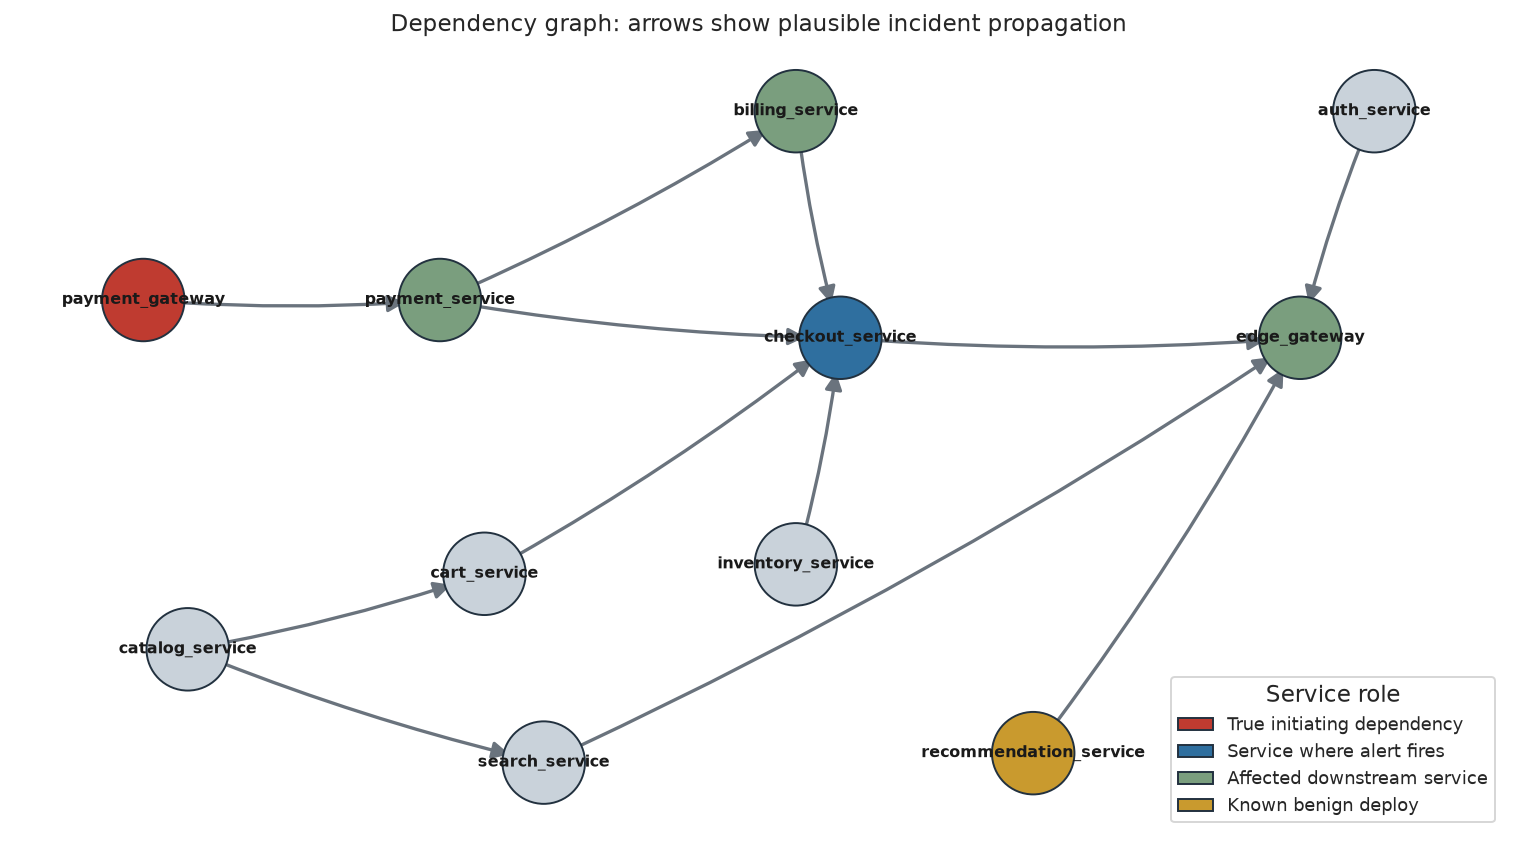

In [2]:
# Section focus: 4. Case Study: Checkout Latency in a Commerce Platform.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

services = [
    'payment_gateway',
    'payment_service',
    'checkout_service',
    'edge_gateway',
    'cart_service',
    'inventory_service',
    'catalog_service',
    'search_service',
    'recommendation_service',
    'auth_service',
    'billing_service',
]

service_edges = [
    ('payment_gateway', 'payment_service'),
    ('payment_service', 'billing_service'),
    ('payment_service', 'checkout_service'),
    ('checkout_service', 'edge_gateway'),
    ('cart_service', 'checkout_service'),
    ('inventory_service', 'checkout_service'),
    ('catalog_service', 'cart_service'),
    ('catalog_service', 'search_service'),
    ('search_service', 'edge_gateway'),
    ('recommendation_service', 'edge_gateway'),
    ('auth_service', 'edge_gateway'),
    ('billing_service', 'checkout_service'),
]

G = nx.DiGraph()
G.add_nodes_from(services)
G.add_edges_from(service_edges)

pos = {
    'payment_gateway': (0.05, 0.62),
    'payment_service': (0.25, 0.62),
    'checkout_service': (0.52, 0.58),
    'edge_gateway': (0.83, 0.58),
    'cart_service': (0.28, 0.33),
    'inventory_service': (0.49, 0.34),
    'billing_service': (0.49, 0.82),
    'catalog_service': (0.08, 0.25),
    'search_service': (0.32, 0.13),
    'recommendation_service': (0.65, 0.14),
    'auth_service': (0.88, 0.82),
}

root_service = 'payment_gateway'
alert_service = 'checkout_service'
benign_service = 'recommendation_service'
propagation_services = {'payment_service', 'checkout_service', 'edge_gateway', 'billing_service'}

def node_color(service):
    """Carry out the node color step used in the 15. From Alerts to Root Cause Analysis workflow.
    
    Parameters
    ----------
    service : object
        The service setting that controls the node color calculation in this notebook.
    
    Returns
    -------
    object
        Graph, figure, or visual specification produced by the node color workflow.
    """
    if service == root_service:
        return '#bf3b30'
    if service == alert_service:
        return '#2f6f9f'
    if service == benign_service:
        return '#c99a2e'
    if service in propagation_services:
        return '#7a9e7e'
    return '#c9d2da'

fig, ax = plt.subplots(figsize=(11, 6.2))
nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=18,
    width=1.7,
    edge_color='#6a737d',
    connectionstyle='arc3,rad=0.04',
    min_source_margin=18,
    min_target_margin=18,
)
nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_color=[node_color(s) for s in G.nodes],
    node_size=1800,
    edgecolors='#22313f',
    linewidths=1.0,
)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
legend_handles = [
    Patch(facecolor='#bf3b30', edgecolor='#22313f', label='True initiating dependency'),
    Patch(facecolor='#2f6f9f', edgecolor='#22313f', label='Service where alert fires'),
    Patch(facecolor='#7a9e7e', edgecolor='#22313f', label='Affected downstream service'),
    Patch(facecolor='#c99a2e', edgecolor='#22313f', label='Known benign deploy'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True, title='Service role')
ax.set_title('Dependency graph: arrows show plausible incident propagation')
ax.set_axis_off()
plt.tight_layout()
plt.show()

The graph tells us which propagation stories are plausible. It does not prove them. The payment gateway can propagate to payment service, then checkout, then edge gateway. The recommendations service can affect the edge gateway but has no direct path into checkout in this simplified service topology.

## 5. Simulating Telemetry and an Incident

We simulate six telemetry channels for every service:

| Metric | Meaning | High values usually imply |
|---|---|---|
| `latency_ms` | Request latency | Slower user or service response |
| `error_rate_pct` | Percent of failed requests | Reliability degradation |
| `timeout_rate_pct` | Percent of timeout failures | Dependency or resource issue |
| `queue_depth` | Work waiting to be processed | Congestion |
| `cpu_pct` | CPU utilization | Saturation risk |
| `request_rate` | Incoming load | Demand shift or exposure |

The incident begins inside `payment_gateway`. A separate recommendations deployment begins nearby in time, but it is not the cause of checkout degradation.

In [3]:
# Section focus: 5. Simulating Telemetry and an Incident.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_microservice_telemetry(seed=RANDOM_SEED):
    """Create a simulated microservice telemetry data set for the 15. From Alerts to Root Cause Analysis case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    times = pd.date_range('2026-03-18 09:00', periods=144, freq='5min')
    incident_start = times[66]
    deploy_start = times[62]

    base = {
        'payment_gateway':       {'latency_ms': 95,  'error_rate_pct': 0.45, 'timeout_rate_pct': 0.20, 'queue_depth': 5,  'cpu_pct': 38, 'request_rate': 220},
        'payment_service':       {'latency_ms': 115, 'error_rate_pct': 0.55, 'timeout_rate_pct': 0.25, 'queue_depth': 8,  'cpu_pct': 42, 'request_rate': 250},
        'checkout_service':      {'latency_ms': 145, 'error_rate_pct': 0.75, 'timeout_rate_pct': 0.35, 'queue_depth': 12, 'cpu_pct': 48, 'request_rate': 310},
        'edge_gateway':          {'latency_ms': 80,  'error_rate_pct': 0.35, 'timeout_rate_pct': 0.15, 'queue_depth': 10, 'cpu_pct': 50, 'request_rate': 920},
        'cart_service':          {'latency_ms': 90,  'error_rate_pct': 0.35, 'timeout_rate_pct': 0.12, 'queue_depth': 7,  'cpu_pct': 39, 'request_rate': 420},
        'inventory_service':     {'latency_ms': 100, 'error_rate_pct': 0.40, 'timeout_rate_pct': 0.16, 'queue_depth': 9,  'cpu_pct': 43, 'request_rate': 300},
        'catalog_service':       {'latency_ms': 75,  'error_rate_pct': 0.25, 'timeout_rate_pct': 0.08, 'queue_depth': 6,  'cpu_pct': 37, 'request_rate': 700},
        'search_service':        {'latency_ms': 95,  'error_rate_pct': 0.30, 'timeout_rate_pct': 0.10, 'queue_depth': 8,  'cpu_pct': 46, 'request_rate': 610},
        'recommendation_service':{'latency_ms': 130, 'error_rate_pct': 0.45, 'timeout_rate_pct': 0.14, 'queue_depth': 11, 'cpu_pct': 54, 'request_rate': 520},
        'auth_service':          {'latency_ms': 65,  'error_rate_pct': 0.20, 'timeout_rate_pct': 0.07, 'queue_depth': 5,  'cpu_pct': 35, 'request_rate': 880},
        'billing_service':       {'latency_ms': 110, 'error_rate_pct': 0.40, 'timeout_rate_pct': 0.18, 'queue_depth': 7,  'cpu_pct': 40, 'request_rate': 210},
    }

    incident_delays = {
        'payment_gateway': 0,
        'payment_service': 1,
        'billing_service': 2,
        'checkout_service': 3,
        'edge_gateway': 5,
    }

    records = []
    for t_idx, timestamp in enumerate(times):
        hour_angle = 2 * np.pi * (t_idx / len(times))
        daily_load = 1.0 + 0.12 * np.sin(hour_angle - 0.5)
        lunch_bump = 1.0 + 0.10 * np.exp(-((t_idx - 54) / 12) ** 2)
        for service in services:
            b = base[service]
            load = daily_load * lunch_bump
            request_rate = b['request_rate'] * load + rng.normal(0, b['request_rate'] * 0.035)
            latency = b['latency_ms'] + rng.normal(0, 7 + 0.02 * b['latency_ms'])
            error = b['error_rate_pct'] + rng.normal(0, 0.08)
            timeout = b['timeout_rate_pct'] + rng.normal(0, 0.05)
            queue = b['queue_depth'] + rng.normal(0, 1.8)
            cpu = b['cpu_pct'] + 0.018 * (request_rate - b['request_rate']) + rng.normal(0, 2.0)

            known_deploy = 0
            if service == benign_service and deploy_start <= timestamp <= deploy_start + pd.Timedelta(minutes=70):
                known_deploy = 1
                elapsed = (timestamp - deploy_start).total_seconds() / 300
                deploy_shape = 1 - np.exp(-elapsed / 4)
                latency += 70 * deploy_shape
                cpu += 8 * deploy_shape
                queue += 5 * deploy_shape

            if service in incident_delays:
                start_idx = 66 + incident_delays[service]
                if t_idx >= start_idx:
                    elapsed = t_idx - start_idx
                    phase = 1 - np.exp(-elapsed / 5)
                    decay = np.exp(-max(elapsed - 45, 0) / 18)
                    intensity = phase * decay
                    if service == 'payment_gateway':
                        timeout += 5.8 * intensity
                        error += 2.5 * intensity
                        latency += 115 * intensity
                        cpu += 8 * intensity
                    elif service == 'payment_service':
                        timeout += 4.1 * intensity
                        error += 2.2 * intensity
                        latency += 145 * intensity
                        queue += 26 * intensity
                        cpu += 12 * intensity
                    elif service == 'billing_service':
                        timeout += 1.8 * intensity
                        error += 1.1 * intensity
                        latency += 70 * intensity
                        queue += 10 * intensity
                    elif service == 'checkout_service':
                        timeout += 2.9 * intensity
                        error += 3.4 * intensity
                        latency += 230 * intensity
                        queue += 38 * intensity
                        cpu += 15 * intensity
                    elif service == 'edge_gateway':
                        error += 1.1 * intensity
                        latency += 95 * intensity
                        queue += 20 * intensity

            records.append({
                'timestamp': timestamp,
                'service': service,
                'latency_ms': max(latency, 1),
                'error_rate_pct': max(error, 0),
                'timeout_rate_pct': max(timeout, 0),
                'queue_depth': max(queue, 0),
                'cpu_pct': np.clip(cpu, 0, 100),
                'request_rate': max(request_rate, 1),
                'known_deploy': known_deploy,
            })

    return pd.DataFrame(records), incident_start, deploy_start

telemetry, incident_start, deploy_start = simulate_microservice_telemetry()

incident_summary = pd.DataFrame([
    {'item': 'Alerted service', 'value': alert_service},
    {'item': 'True initiating dependency in simulation', 'value': root_service},
    {'item': 'Payment issue begins', 'value': incident_start.strftime('%Y-%m-%d %H:%M')},
    {'item': 'Nearby benign recommendations deploy', 'value': deploy_start.strftime('%Y-%m-%d %H:%M')},
    {'item': 'Telemetry rows', 'value': f'{len(telemetry):,}'},
])
incident_summary

,item,value
0,Alerted service,checkout_service
1,True initiating dependency in simulation,payment_gateway
2,Payment issue begins,2026-03-18 14:30
3,Nearby benign recommendations deploy,2026-03-18 14:10
4,Telemetry rows,"1,584"


The table above is information we would never fully know during a live incident. In the notebook we keep the simulated truth visible so we can check whether the RCA workflow behaves sensibly.

In Simulating Telemetry and an Incident, the detector earns its keep only if the output sharpens the review queue.


## 6. Robust Service-Level Anomaly Scores

For each service and metric, compute a robust reference distribution from the pre-incident period. For metric $k$ in service $s$, define

$$
Z_{s,t,k} = \frac{Y_{s,t,k} - \mathrm{median}(Y_{s,\mathrm{ref},k})}{1.4826 \cdot \mathrm{MAD}(Y_{s,\mathrm{ref},k}) + \epsilon}.
$$

For high-is-bad metrics, we keep the positive part. For request rate, both high and low deviations may matter, so we use absolute deviation. Then we aggregate metric evidence into a service score:

$$
A_{s,t} = \sqrt{\frac{\sum_k w_k Z_{s,t,k}^{2}}{\sum_k w_k}}.
$$

This is intentionally transparent. A production system might use more sophisticated detectors, but root-cause workflows still need interpretable evidence.

In [4]:
# Section focus: 6. Robust Service-Level Anomaly Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

metrics = ['latency_ms', 'error_rate_pct', 'timeout_rate_pct', 'queue_depth', 'cpu_pct', 'request_rate']
metric_weights = {
    'latency_ms': 1.00,
    'error_rate_pct': 1.20,
    'timeout_rate_pct': 1.35,
    'queue_depth': 0.85,
    'cpu_pct': 0.55,
    'request_rate': 0.35,
}

reference_mask = telemetry['timestamp'] < incident_start - pd.Timedelta(minutes=30)
scored = telemetry.copy()

for metric in metrics:
    scored[f'{metric}_z'] = np.nan

for service, service_df in telemetry.groupby('service'):
    ref = service_df.loc[reference_mask.loc[service_df.index], metrics]
    med = ref.median()
    mad = (ref - med).abs().median().replace(0, 1e-6)
    denom = 1.4826 * mad + 1e-6
    idx = scored['service'].eq(service)
    for metric in metrics:
        raw_z = (scored.loc[idx, metric] - med[metric]) / denom[metric]
        if metric == 'request_rate':
            z = raw_z.abs()
        else:
            z = raw_z.clip(lower=0)
        scored.loc[idx, f'{metric}_z'] = z

weighted_terms = []
for metric in metrics:
    weighted_terms.append(metric_weights[metric] * scored[f'{metric}_z'] ** 2)
scored['service_score'] = np.sqrt(np.sum(weighted_terms, axis=0) / sum(metric_weights.values()))

reference_scores = scored.loc[reference_mask, 'service_score']
alert_threshold = max(4.0, np.quantile(reference_scores, 0.997) + 1.0)

checkout_scores = scored.query('service == @alert_service').sort_values('timestamp')
alert_candidates = checkout_scores.loc[checkout_scores['service_score'] >= alert_threshold, 'timestamp']
alert_time = alert_candidates.iloc[0]

score_snapshot = (
    scored.loc[(scored['timestamp'] >= incident_start - pd.Timedelta(minutes=20)) &
               (scored['timestamp'] <= incident_start + pd.Timedelta(minutes=60))]
    .groupby('service')
    .agg(peak_score=('service_score', 'max'), deploy_seen=('known_deploy', 'max'))
    .sort_values('peak_score', ascending=False)
    .round(2)
)

print(f'Alert threshold: {alert_threshold:.2f}')
print(f'Checkout alert time: {alert_time:%Y-%m-%d %H:%M}')
score_snapshot.head(8)

Alert threshold: 4.00
Checkout alert time: 2026-03-18 14:50


,peak_score,deploy_seen
service,,
payment_gateway,43.37,0
payment_service,40.44,0
checkout_service,30.94,0
billing_service,14.30,0
edge_gateway,6.95,0
recommendation_service,4.06,1
search_service,1.63,0
catalog_service,1.23,0


A high score means unusual telemetry relative to that service's own baseline. It does not yet separate root causes from propagated symptoms.

The practical reading of Robust Service-Level Anomaly Scores is whether the flagged cases point to an action a team can defend.


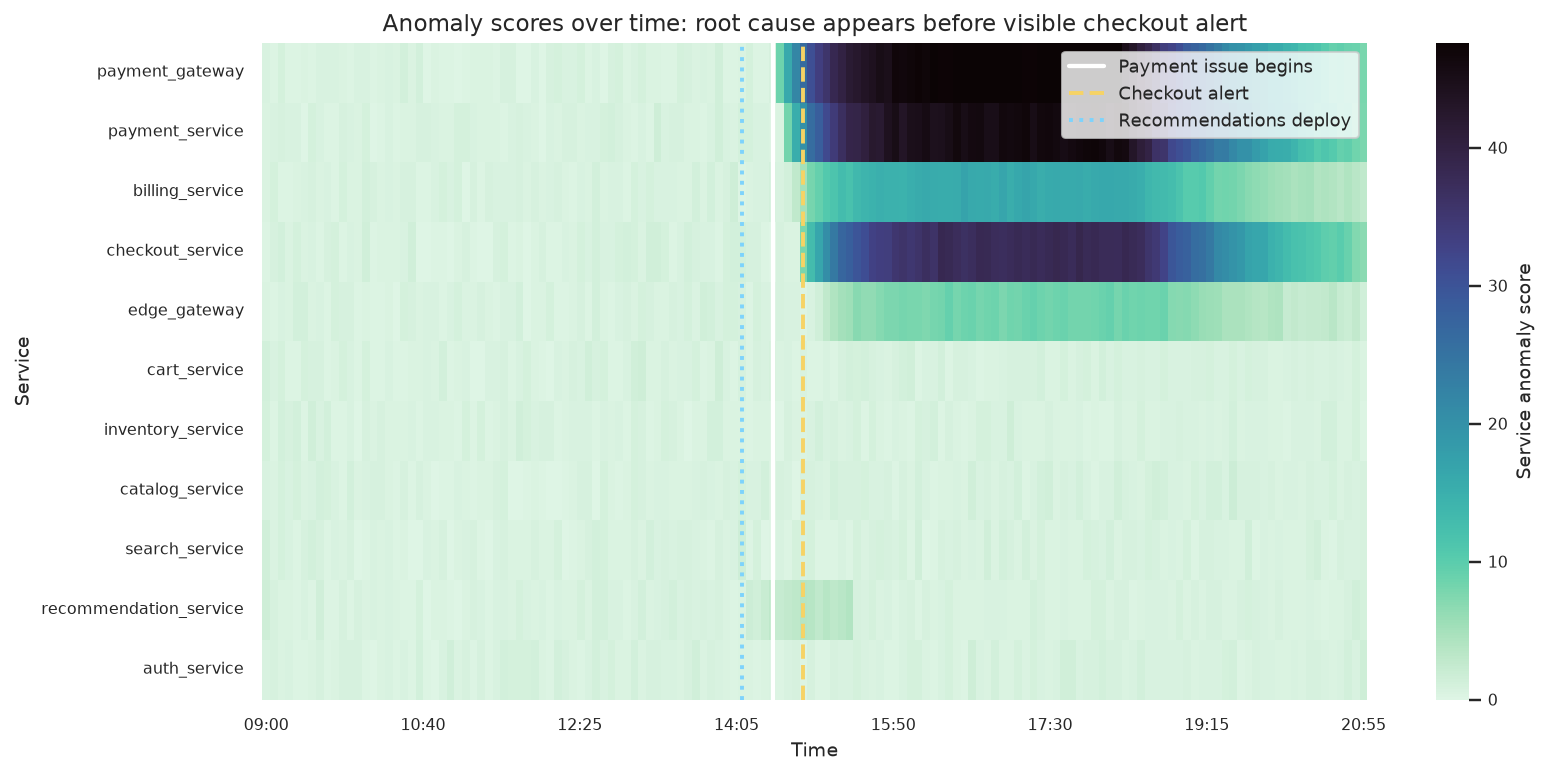

In [5]:
# Section focus: 6. Robust Service-Level Anomaly Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

score_matrix = scored.pivot_table(index='service', columns='timestamp', values='service_score', aggfunc='mean')
service_order = [
    'payment_gateway', 'payment_service', 'billing_service', 'checkout_service', 'edge_gateway',
    'cart_service', 'inventory_service', 'catalog_service', 'search_service', 'recommendation_service', 'auth_service'
]
score_matrix = score_matrix.loc[service_order]

fig, ax = plt.subplots(figsize=(12, 5.7))
sns.heatmap(
    score_matrix,
    cmap='mako_r',
    vmin=0,
    vmax=np.nanpercentile(score_matrix.values, 99),
    cbar_kws={'label': 'Service anomaly score'},
    ax=ax,
)
columns = list(score_matrix.columns)
incident_x = columns.index(incident_start) + 0.5
alert_x = columns.index(alert_time) + 0.5
deploy_x = columns.index(deploy_start) + 0.5
ax.axvline(incident_x, color='white', linestyle='-', linewidth=2.2, label='Payment issue begins')
ax.axvline(alert_x, color='#f6d365', linestyle='--', linewidth=2.0, label='Checkout alert')
ax.axvline(deploy_x, color='#7dd3fc', linestyle=':', linewidth=2.0, label='Recommendations deploy')
xtick_positions = np.linspace(0.5, len(columns) - 0.5, 8)
xtick_labels = [columns[int(round(x - 0.5))].strftime('%H:%M') for x in xtick_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=0)
ax.set_xlabel('Time')
ax.set_ylabel('Service')
ax.set_title('Anomaly scores over time: root cause appears before visible checkout alert')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

The heatmap reveals the RCA challenge. Several services become anomalous in a short window. The payment gateway is early, checkout is visible, and recommendations has an unrelated anomaly. Without topology and timing, all three can look plausible.

For Robust Service-Level Anomaly Scores, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


## 7. Candidate Evidence: Topology, Timing, Strength, and Blast Radius

We will construct one row per candidate service. A good root-cause candidate should generally satisfy four checks:

1. It is upstream of the alerted service.
2. It becomes anomalous before or near the alert.
3. Its local anomaly is substantial.
4. Downstream services become anomalous after it.

A known benign change should lower service priority unless other evidence supports escalation.

In [6]:
service_scores = scored[['timestamp', 'service', 'service_score', 'known_deploy']].copy()
window_mask = (
    service_scores['timestamp'].between(incident_start - pd.Timedelta(minutes=25), alert_time + pd.Timedelta(minutes=70))
)
window_scores = service_scores.loc[window_mask]

first_anomaly = (
    service_scores.loc[service_scores['service_score'] >= alert_threshold]
    .groupby('service')['timestamp']
    .min()
)
peak_score = window_scores.groupby('service')['service_score'].max()

def graph_distance_to_alert(service):
    """Carry out the graph distance to alert step used in the 15. From Alerts to Root Cause Analysis workflow.
    
    Parameters
    ----------
    service : object
        The service setting that controls the graph distance to alert calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the graph distance to alert calculation.
    """
    if service == alert_service:
        return 0
    if nx.has_path(G, service, alert_service):
        return nx.shortest_path_length(G, service, alert_service)
    return np.nan

def downstream_blast_score(service):
    """Carry out the downstream blast score step used in the 15. From Alerts to Root Cause Analysis workflow.
    
    Parameters
    ----------
    service : object
        The service setting that controls the downstream blast score calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the downstream blast score calculation.
    """
    descendants = list(nx.descendants(G, service))
    if not descendants or service not in first_anomaly:
        return 0.0
    start = first_anomaly[service]
    if pd.isna(start):
        return 0.0
    eligible = []
    for downstream in descendants:
        if downstream in first_anomaly:
            dt = (first_anomaly[downstream] - start).total_seconds() / 60
            if 0 <= dt <= 45:
                eligible.append(downstream)
    return len(eligible) / len(descendants)

rows = []
for service in services:
    first_time = first_anomaly.get(service, pd.NaT)
    distance = graph_distance_to_alert(service)
    has_threshold_crossing = service in first_anomaly
    if service == alert_service:
        # The alerted service can be the local cause, but it should not receive
        # maximum upstream credit merely because the alert fired there.
        upstream_score = 0.35
    elif pd.isna(distance):
        upstream_score = 0.0
    else:
        # In RCA, path existence is often more important than exact path length:
        # a farther upstream dependency can be the initiating cause.
        upstream_score = 1.0
    if not has_threshold_crossing:
        # A service can be structurally upstream without being incident-relevant.
        # Keep a small topology prior, but do not let topology dominate evidence.
        upstream_score *= 0.25
    if pd.isna(first_time):
        lead_minutes = np.nan
        lead_score = 0.0
    else:
        lead_minutes = (alert_time - first_time).total_seconds() / 60
        lead_score = np.clip(lead_minutes / 30, 0, 1)
    strength_score = np.clip(peak_score.get(service, 0) / 10, 0, 1)
    blast_score = downstream_blast_score(service)
    benign_penalty = 1.0 if window_scores.query('service == @service')['known_deploy'].max() == 1 else 0.0
    rca_score = (
        0.32 * upstream_score
        + 0.24 * lead_score
        + 0.24 * strength_score
        + 0.20 * blast_score
        - 0.25 * benign_penalty
    )
    rows.append({
        'service': service,
        'first_anomaly_time': first_time,
        'lead_minutes_before_alert': lead_minutes,
        'graph_distance_to_checkout': distance,
        'upstream_evidence': upstream_score,
        'timing_evidence': lead_score,
        'local_strength': strength_score,
        'blast_radius_evidence': blast_score,
        'known_benign_change_penalty': benign_penalty,
        'rca_score': rca_score,
        'peak_score': peak_score.get(service, np.nan),
    })

rca_table = pd.DataFrame(rows).sort_values('rca_score', ascending=False).reset_index(drop=True)
rca_display = rca_table.copy()
rca_display['first_anomaly_time'] = rca_display['first_anomaly_time'].dt.strftime('%H:%M').fillna('No threshold crossing')
rca_display['graph_distance_to_checkout'] = rca_display['graph_distance_to_checkout'].apply(
    lambda x: 'Not upstream' if pd.isna(x) else int(x)
)
rca_display[['service', 'first_anomaly_time', 'lead_minutes_before_alert', 'graph_distance_to_checkout', 'peak_score', 'rca_score']].round(2).head(8)

,service,first_anomaly_time,lead_minutes_before_alert,graph_distance_to_checkout,peak_score,rca_score
0,payment_gateway,14:35,15.0,2,46.94,0.88
1,payment_service,14:40,10.0,1,45.28,0.84
2,billing_service,14:50,0.0,1,15.22,0.76
3,checkout_service,14:50,0.0,0,35.77,0.55
4,edge_gateway,15:10,-20.0,Not upstream,8.17,0.20
5,cart_service,No threshold crossing,NaN,1,1.47,0.12
6,catalog_service,No threshold crossing,NaN,2,1.23,0.11
7,inventory_service,No threshold crossing,NaN,1,1.12,0.11


The table is deliberately transparent. Each candidate can be challenged: Is the dependency edge real? Did telemetry arrive late? Was the deploy actually benign? Did a hidden shared dependency create a false path?

Candidate Evidence: Topology, Timing, Strength, and Blast Radius should make triage easier. The score or summary needs to point to actionable risk rather than ordinary variation or measurement noise.


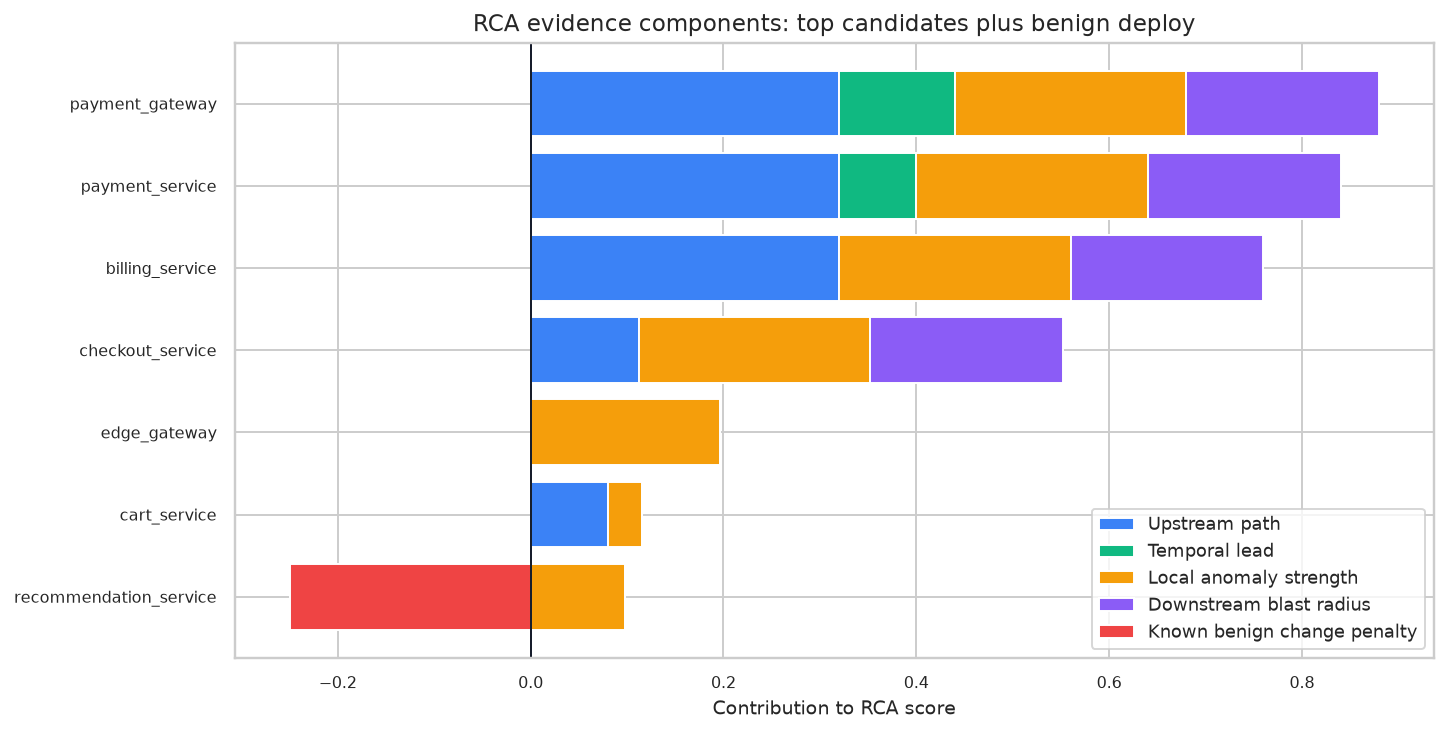

In [7]:
# Section focus: 7. Candidate Evidence: Topology, Timing, Strength, and Blast Radius.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

component_services = rca_table.head(6)['service'].tolist()
if benign_service not in component_services:
    component_services.append(benign_service)
top_components = rca_table.set_index('service').loc[component_services].reset_index()
component_cols = ['upstream_evidence', 'timing_evidence', 'local_strength', 'blast_radius_evidence']
component_weights = {
    'upstream_evidence': 0.32,
    'timing_evidence': 0.24,
    'local_strength': 0.24,
    'blast_radius_evidence': 0.20,
}
plot_components = top_components[['service']].copy()
for col in component_cols:
    plot_components[col] = top_components[col] * component_weights[col]
plot_components['known_benign_change_penalty'] = -0.25 * top_components['known_benign_change_penalty']

fig, ax = plt.subplots(figsize=(10.5, 5.4))
y = np.arange(len(plot_components))
left = np.zeros(len(plot_components))
colors = {
    'upstream_evidence': '#3b82f6',
    'timing_evidence': '#10b981',
    'local_strength': '#f59e0b',
    'blast_radius_evidence': '#8b5cf6',
}
labels = {
    'upstream_evidence': 'Upstream path',
    'timing_evidence': 'Temporal lead',
    'local_strength': 'Local anomaly strength',
    'blast_radius_evidence': 'Downstream blast radius',
}
for col in component_cols:
    ax.barh(y, plot_components[col], left=left, color=colors[col], label=labels[col])
    left += plot_components[col].to_numpy()
penalty = plot_components['known_benign_change_penalty'].to_numpy()
ax.barh(y, penalty, color='#ef4444', label='Known benign change penalty')
ax.axvline(0, color='#111827', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_components['service'])
ax.invert_yaxis()
ax.set_xlabel('Contribution to RCA score')
ax.set_title('RCA evidence components: top candidates plus benign deploy')
ax.legend(loc='lower right', frameon=True, ncol=1)
plt.tight_layout()
plt.show()

This ranking makes the payment gateway the leading hypothesis because it is upstream, early, locally anomalous, and followed by downstream anomalies. The recommendations service has local anomaly evidence, but the known deploy and graph position weaken the case that it caused the checkout alert.

In Candidate Evidence: Topology, Timing, Strength, and Blast Radius, the detector is useful only if it points to a defensible next action. Routine variation and known seasonality should stay out of the urgent review queue.


## 8. Why Severity Alone Can Mislead

A naive incident ranking might sort services by visible impact. That is useful for prioritizing customer communication, but it can confuse symptoms with causes.

Below, we build a simple **business impact severity** score by multiplying peak anomaly score, average request rate, and a customer-exposure weight. This intentionally emphasizes user-facing services rather than hidden infrastructure dependencies.

In [8]:
# Section focus: 8. Why Severity Alone Can Mislead.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

impact_table = (
    scored.loc[window_mask]
    .groupby('service')
    .agg(
        peak_score=('service_score', 'max'),
        avg_request_rate=('request_rate', 'mean'),
        known_deploy=('known_deploy', 'max'),
    )
    .reset_index()
)
customer_exposure_weight = {
    'edge_gateway': 1.00,
    'checkout_service': 0.85,
    'payment_service': 0.35,
    'payment_gateway': 0.20,
    'cart_service': 0.45,
    'inventory_service': 0.25,
    'catalog_service': 0.40,
    'search_service': 0.55,
    'recommendation_service': 0.55,
    'auth_service': 0.55,
    'billing_service': 0.20,
}
impact_table['customer_exposure_weight'] = impact_table['service'].map(customer_exposure_weight)
impact_table['business_impact_severity'] = (
    impact_table['peak_score']
    * np.log1p(impact_table['avg_request_rate'])
    * impact_table['customer_exposure_weight']
)
impact_table['impact_rank'] = impact_table['business_impact_severity'].rank(ascending=False, method='first').astype(int)
impact_table = impact_table.sort_values('business_impact_severity', ascending=False)

comparison = (
    impact_table[['service', 'impact_rank', 'customer_exposure_weight', 'business_impact_severity']]
    .merge(rca_table[['service', 'rca_score']], on='service')
    .sort_values('impact_rank')
)
comparison['rca_rank'] = comparison['rca_score'].rank(ascending=False, method='first').astype(int)
comparison.round(2).head(8)

,service,impact_rank,customer_exposure_weight,business_impact_severity,rca_score,rca_rank
0,checkout_service,1,0.85,176.85,0.55,4
1,payment_service,2,0.35,88.68,0.84,2
2,edge_gateway,3,1.00,56.32,0.20,5
3,payment_gateway,4,0.20,51.35,0.88,1
4,billing_service,5,0.20,16.53,0.76,3
5,recommendation_service,6,0.55,14.16,-0.15,11
6,search_service,7,0.55,5.81,0.04,9
7,auth_service,8,0.55,4.08,0.03,10


Why Severity Alone Can Mislead is less about the score itself and more about whether the score creates an actionable investigation path.


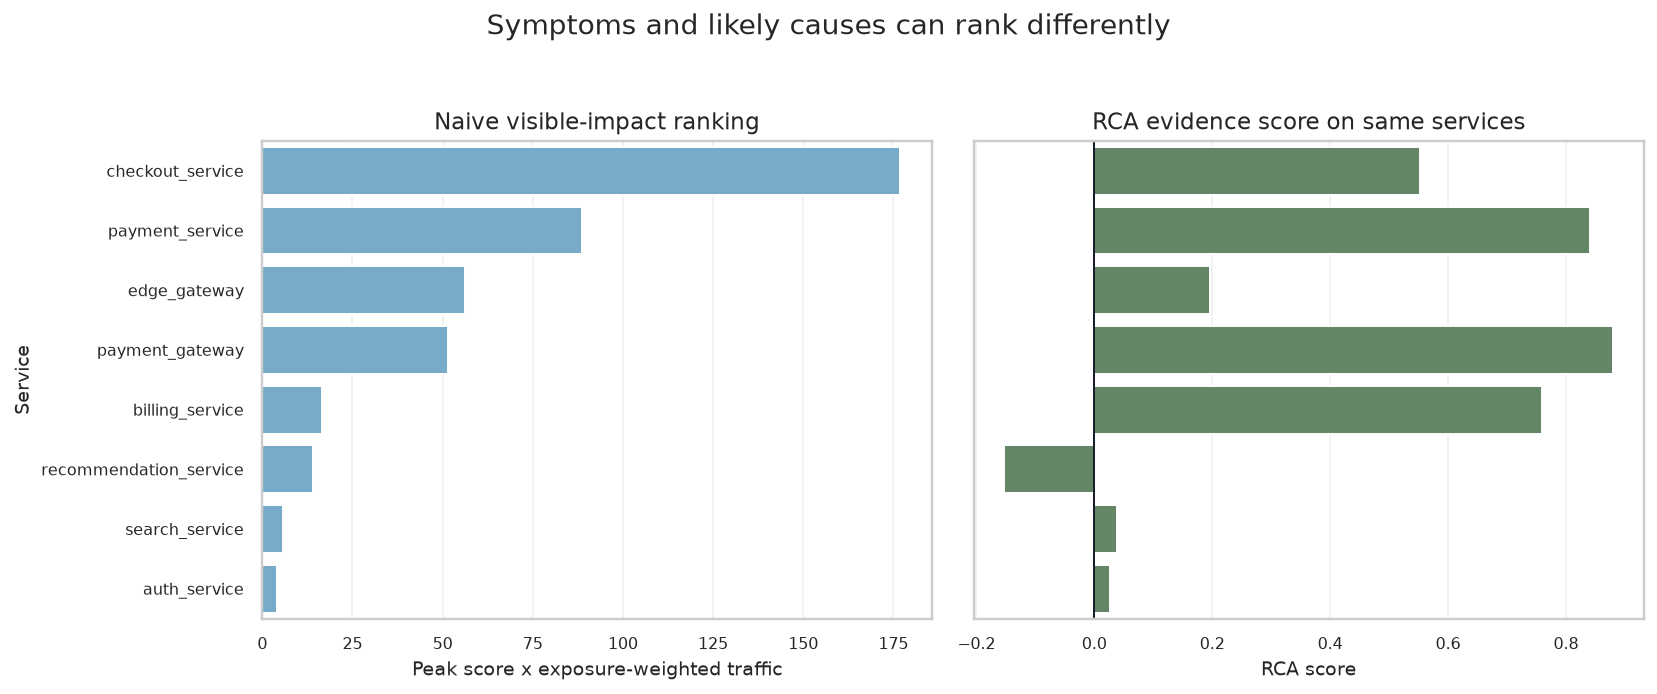

In [9]:
# Section focus: 8. Why Severity Alone Can Mislead.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_compare = comparison.head(8).copy()
service_plot_order = plot_compare['service'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

sns.barplot(
    data=plot_compare,
    y='service',
    x='business_impact_severity',
    order=service_plot_order,
    color='#6aaed6',
    ax=axes[0],
)
axes[0].set_title('Naive visible-impact ranking')
axes[0].set_xlabel('Peak score x exposure-weighted traffic')
axes[0].set_ylabel('Service')

sns.barplot(
    data=plot_compare,
    y='service',
    x='rca_score',
    order=service_plot_order,
    color='#5e8c61',
    ax=axes[1],
)
axes[1].axvline(0, color='#111827', linewidth=1)
axes[1].set_title('RCA evidence score on same services')
axes[1].set_xlabel('RCA score')
axes[1].set_ylabel('')

for ax in axes:
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('Symptoms and likely causes can rank differently', y=1.03)
plt.tight_layout()
plt.show()

The left plot is not wrong. It answers a different question: where is the incident most visible? The right plot answers: which service is the best current root-cause hypothesis? Mature incident response usually needs both views.

Read Why Severity Alone Can Mislead with the reviewer in mind. The result should help distinguish signal from ordinary system movement.


## 9. Temporal Propagation Diagnostics

Timing is not causality, but it is a powerful falsification tool. A service that becomes anomalous only after the checkout alert is a weaker initiating-cause hypothesis than a service that became anomalous earlier and lies upstream.

We examine normalized metric trajectories for the suspected propagation chain.

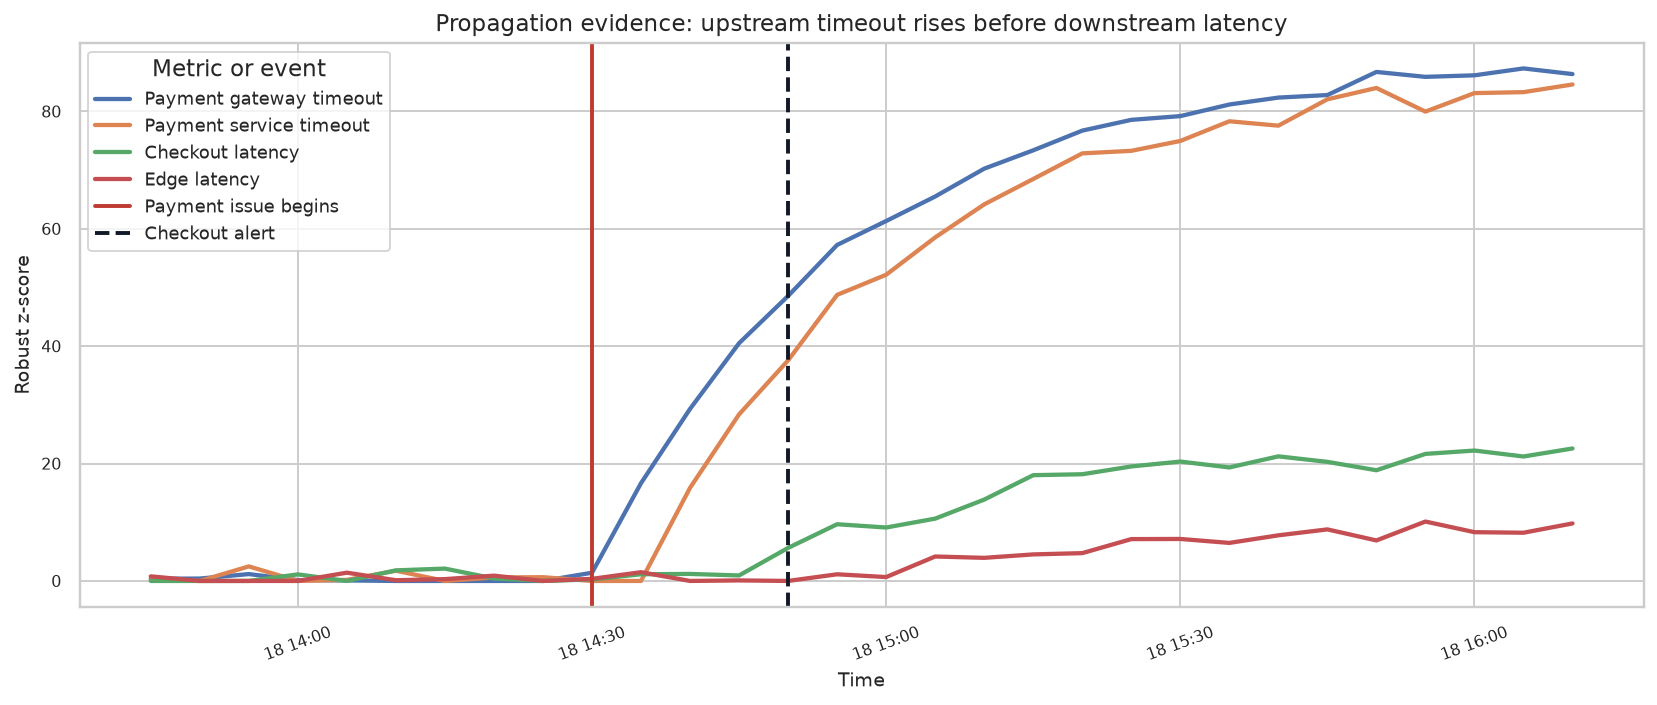

In [10]:
# Section focus: 9. Temporal Propagation Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

chain_specs = [
    ('payment_gateway', 'timeout_rate_pct_z', 'Payment gateway timeout'),
    ('payment_service', 'timeout_rate_pct_z', 'Payment service timeout'),
    ('checkout_service', 'latency_ms_z', 'Checkout latency'),
    ('edge_gateway', 'latency_ms_z', 'Edge latency'),
]

chain_rows = []
for service, metric_z, label in chain_specs:
    temp = scored.loc[scored['service'].eq(service), ['timestamp', metric_z]].copy()
    temp = temp.rename(columns={metric_z: 'normalized_metric'})
    temp['series'] = label
    chain_rows.append(temp)
chain_df = pd.concat(chain_rows, ignore_index=True)
chain_df = chain_df.loc[
    chain_df['timestamp'].between(incident_start - pd.Timedelta(minutes=45), alert_time + pd.Timedelta(minutes=80))
]

fig, ax = plt.subplots(figsize=(12, 5.2))
sns.lineplot(data=chain_df, x='timestamp', y='normalized_metric', hue='series', linewidth=2.2, ax=ax)
ax.axvline(incident_start, color='#bf3b30', linestyle='-', linewidth=2, label='Payment issue begins')
ax.axvline(alert_time, color='#111827', linestyle='--', linewidth=2, label='Checkout alert')
ax.set_title('Propagation evidence: upstream timeout rises before downstream latency')
ax.set_xlabel('Time')
ax.set_ylabel('Robust z-score')
ax.legend(loc='upper left', frameon=True, title='Metric or event')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In Temporal Propagation Diagnostics, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


In [11]:
# Section focus: 9. Temporal Propagation Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

root_series = (
    scored.loc[scored['service'].eq(root_service)]
    .sort_values('timestamp')
    .set_index('timestamp')['service_score']
)

root_first_anomaly = first_anomaly.get(root_service, pd.NaT)

lag_rows = []
for service in ['payment_service', 'billing_service', 'checkout_service', 'edge_gateway', 'recommendation_service']:
    target = (
        scored.loc[scored['service'].eq(service)]
        .sort_values('timestamp')
        .set_index('timestamp')['service_score']
        .reindex(root_series.index)
    )
    best_lag = None
    best_corr = -np.inf
    for lag in range(0, 9):
        if lag == 0:
            corr = root_series.corr(target)
        else:
            corr = root_series.iloc[:-lag].corr(target.iloc[lag:])
        if pd.notna(corr) and corr > best_corr:
            best_corr = corr
            best_lag = lag * 5
    service_first = first_anomaly.get(service, pd.NaT)
    if pd.isna(service_first) or pd.isna(root_first_anomaly):
        onset_delay = np.nan
    else:
        onset_delay = (service_first - root_first_anomaly).total_seconds() / 60
    lag_rows.append({
        'target_service': service,
        'onset_delay_after_root_minutes': onset_delay,
        'best_correlation_lag_minutes': best_lag,
        'max_lagged_correlation': best_corr,
        'reachable_from_payment_gateway': nx.has_path(G, root_service, service),
    })

lag_table = pd.DataFrame(lag_rows).sort_values('onset_delay_after_root_minutes')
lag_table.round(3)

,target_service,onset_delay_after_root_minutes,best_correlation_lag_minutes,max_lagged_correlation,reachable_from_payment_gateway
0,payment_service,5.0,0,0.997,True
1,billing_service,15.0,0,0.990,True
2,checkout_service,15.0,0,0.979,True
3,edge_gateway,35.0,0,0.947,True
4,recommendation_service,45.0,10,0.117,False


Lagged correlation should be read carefully. It supports a propagation story when it agrees with topology and onset timing. It is weak evidence when a service is not reachable from the candidate cause, when a known external event explains the pattern, or when a long incident plateau makes the best correlation lag collapse toward zero.

## 10. From Candidate Cause to Action

RCA is useful only if it changes the next action. For each candidate, we should ask:

- What check would confirm or weaken this hypothesis?
- What mitigation could be attempted?
- What is the risk of acting on this hypothesis too early?
- What evidence should be collected for post-incident learning?

In [12]:
action_table = pd.DataFrame([
    {
        'candidate': 'payment_gateway',
        'confirming_check': 'Inspect gateway timeout logs, provider status, retries, and recent network errors.',
        'first_mitigation': 'Enable fallback provider or reduce retry amplification while checkout queue drains.',
        'risk_if_wrong': 'May shift traffic unnecessarily or hide an unrelated checkout defect.',
    },
    {
        'candidate': 'checkout_service',
        'confirming_check': 'Inspect application errors, queue saturation, and deployment diff around alert time.',
        'first_mitigation': 'Scale workers or rollback only if local checkout errors precede dependency errors.',
        'risk_if_wrong': 'Treats the symptom and leaves upstream payment failures active.',
    },
    {
        'candidate': 'recommendation_service',
        'confirming_check': 'Check whether edge latency changed only for personalized pages and whether checkout calls depend on recommendations.',
        'first_mitigation': 'Disable recommendations for affected pages if customer-visible edge latency dominates.',
        'risk_if_wrong': 'Distracts from payment path and burns response time on a benign deploy.',
    },
])

action_table

,candidate,confirming_check,first_mitigation,risk_if_wrong
0,payment_gateway,"Inspect gateway timeout logs, provider status, retries, and recent network errors.",Enable fallback provider or reduce retry amplification while checkout queue drains.,May shift traffic unnecessarily or hide an unrelated checkout defect.
1,checkout_service,"Inspect application errors, queue saturation, and deployment diff around alert time.",Scale workers or rollback only if local checkout errors precede dependency errors.,Treats the symptom and leaves upstream payment failures active.
2,recommendation_service,Check whether edge latency changed only for personalized pages and whether checkout calls depend on recommendations.,Disable recommendations for affected pages if customer-visible edge latency dominates.,Distracts from payment path and burns response time on a benign deploy.


Notice that the recommended action is a short, evidence-guided sequence: confirm, mitigate, monitor, and update the hypothesis.

For From Candidate Cause to Action, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


## 11. Incident Memo

A useful incident memo separates the evidence from the recommendation. It should be explicit about uncertainty and about what would change the conclusion.

In [13]:
top = rca_table.iloc[0]
second = rca_table.iloc[1]

display(Markdown(f'''
### Root-Cause Hypothesis

The leading root-cause hypothesis is **{top['service']}** with RCA score **{top['rca_score']:.2f}**. The next strongest candidate is **{second['service']}** with RCA score **{second['rca_score']:.2f}**.

### Evidence

- The candidate is upstream of `{alert_service}` in the dependency graph.
- Its first anomaly occurs before the checkout alert.
- Its local anomaly strength is high in the incident window.
- Downstream services become anomalous after the candidate.
- The recommendations deployment is visible, but topology and penalty evidence make it less likely to explain checkout degradation.

### Recommended Next Actions

1. Confirm payment gateway timeout logs and provider status around **{incident_start:%H:%M}**.
2. Temporarily reduce retry amplification and route eligible transactions through fallback payment capacity.
3. Watch checkout latency and queue depth for recovery after payment mitigation.
4. Preserve logs, traces, deploy metadata, and customer-impact measures for post-incident review.

### Uncertainty

This is not causal proof. The ranking assumes the topology is current, telemetry timestamps are reliable, and no hidden shared dependency is missing. If checkout errors are found to precede payment gateway timeouts in traces, the ranking should be revised.
'''))


### Root-Cause Hypothesis

The leading root-cause hypothesis is **payment_gateway** with RCA score **0.88**. The next strongest candidate is **payment_service** with RCA score **0.84**.

### Evidence

- The candidate is upstream of `checkout_service` in the dependency graph.
- Its first anomaly occurs before the checkout alert.
- Its local anomaly strength is high in the incident window.
- Downstream services become anomalous after the candidate.
- The recommendations deployment is visible, but topology and penalty evidence make it less likely to explain checkout degradation.

### Recommended Next Actions

1. Confirm payment gateway timeout logs and provider status around **14:30**.
2. Temporarily reduce retry amplification and route eligible transactions through fallback payment capacity.
3. Watch checkout latency and queue depth for recovery after payment mitigation.
4. Preserve logs, traces, deploy metadata, and customer-impact measures for post-incident review.

### Uncertainty

This is not causal proof. The ranking assumes the topology is current, telemetry timestamps are reliable, and no hidden shared dependency is missing. If checkout errors are found to precede payment gateway timeouts in traces, the ranking should be revised.


Incident Memo should be read as an operations question. The score should help reviewers focus, rather than simply add another number to the queue.


## 12. Practical Failure Modes

Root-cause analysis is especially vulnerable to failure modes that pure detection notebooks often hide.

| Failure mode | How it shows up | Guardrail |
|---|---|---|
| Stale topology | RCA follows dependency edges that no longer exist | Refresh graph from traces and service registry |
| Missing shared dependency | Multiple services fail together but no common parent appears | Search logs, infra metrics, and network telemetry |
| Timestamp skew | Apparent lead-lag order is wrong | Check clock sync and ingestion delay |
| Alert threshold bias | Later symptoms look more important because they crossed thresholds first | Use continuous scores and pre-alert windows |
| Planned change confusion | Deploys are blamed for unrelated incidents | Combine deploy metadata with path and timing evidence |
| Auto-remediation masking | Recovery begins before analysts inspect the system | Preserve intervention logs and replayable evidence |

The decision-science posture is to make assumptions visible. A brittle RCA pipeline that admits uncertainty is more useful than a confident dashboard that hides it.

## 13. Key Takeaways

- Root-cause analysis starts after detection; it should not be collapsed into anomaly scoring.
- The highest-impact service is often where the symptom is visible, not where the incident began.
- Dependency graphs, timing, local anomaly strength, and blast radius provide complementary evidence.
- RCA scores should be auditable: every term should correspond to a checkable operational claim.
- Incident memos should state the leading hypothesis, the evidence, the recommended action, and the conditions under which the conclusion should change.

## References

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Liu, D., He, C., Peng, X., Lin, F., Zhang, C., Gong, S., Li, Z., Ou, J., & Wu, Z. (2021). MicroHECL: High-efficient root cause localization in large-scale microservice systems. *IEEE/ACM 43rd International Conference on Software Engineering: Software Engineering in Practice*, 338-347. [https://doi.org/10.1109/ICSE-SEIP52600.2021.00043](https://doi.org/10.1109/ICSE-SEIP52600.2021.00043)

Wang, P., Xu, J., Ma, M., Lin, W., Pan, D., Wang, Y., & Chen, P. (2018). CloudRanger: Root cause identification for cloud native systems. *18th IEEE/ACM International Symposium on Cluster, Cloud and Grid Computing*, 492-502. [https://doi.org/10.1109/CCGRID.2018.00076](https://doi.org/10.1109/CCGRID.2018.00076)

Zhang, Y., Guan, Z., Qian, H., Xu, L., Liu, H., Wen, Q., Sun, L., Jiang, J., Fan, L., & Ke, M. (2021). CloudRCA: A root cause analysis framework for cloud computing platforms. *arXiv*. [https://doi.org/10.48550/arXiv.2111.03753](https://doi.org/10.48550/arXiv.2111.03753)
